# Phase 3: The NeuroGym Data Tour
Before we train the RNN, we need to understand what the data actually looks like. NeuroGym generates cognitive tasks with specific temporal phases:
1. **Fixation:** The network must output a 'fixation' action (usually class 0) and wait.
2. **Stimulus:** The noisy evidence is presented. The network must continue to fixate while internally accumulating evidence.
3. **Decision:** The stimulus turns off, and the network must output its choice based on the accumulated evidence.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from src.tasks.data_loader import load_mante_data

print("Loading datasets...")
# We use subsample_step=20 just for visual plotting clarity (fewer data points on the X axis)
context_loader = load_mante_data('../src/tasks/data/tiny_test/context/train.npz', batch_size=1, shuffle=True, subsample_step=20)
perceptual_loader = load_mante_data('../src/tasks/data/tiny_test/perceptual/train.npz', batch_size=1, shuffle=True, subsample_step=20)

# Pull one single trial from each
ctx_obs, ctx_labels, ctx_periods, ctx_coh, ctx_ctx = next(iter(context_loader))
per_obs, per_labels, per_periods, per_coh, per_ctx = next(iter(perceptual_loader))

# Remove batch dimension for plotting: shape becomes (Timesteps, Features)
ctx_obs = ctx_obs.squeeze(0).numpy()
ctx_labels = ctx_labels.squeeze(0).numpy()

per_obs = per_obs.squeeze(0).numpy()
per_labels = per_labels.squeeze(0).numpy()

print("Data loaded successfully!")

Loading datasets...
Data loaded successfully!


### Visualizing Perceptual Decision Making (Low Integration)
In this task, the network receives a single stream of noisy evidence (e.g., dots moving left or right). Notice how the target changes from `0` (Fixate) to the correct choice (e.g., `1` or `2`) at the very end of the trial.

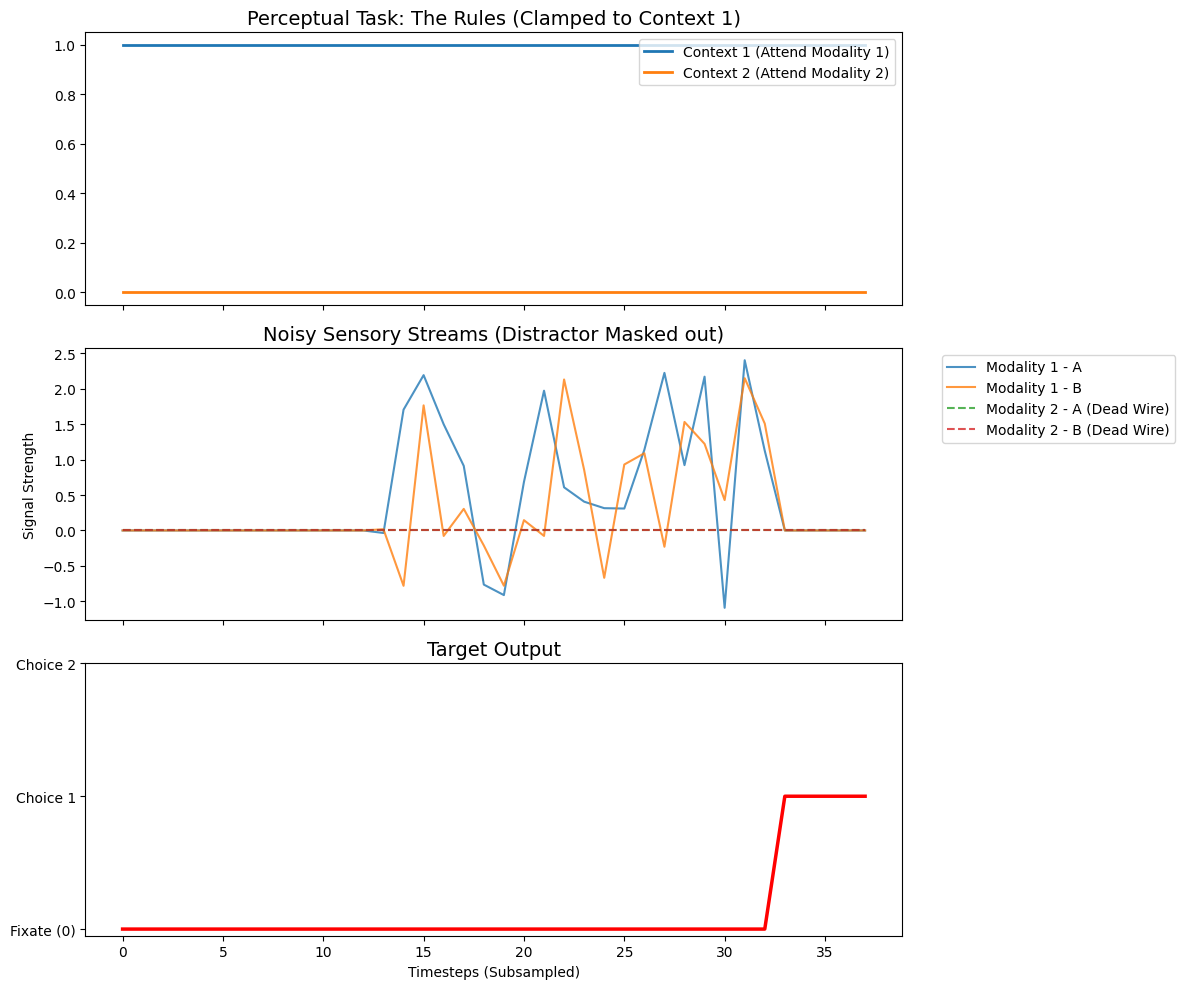

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Plot the Rules (Context Cues) - Notice how it is Clamped!
axes[0].plot(per_obs[:, 5], label="Context 1 (Attend Modality 1)", color="#1f77b4", linewidth=2)
axes[0].plot(per_obs[:, 6], label="Context 2 (Attend Modality 2)", color="#ff7f0e", linewidth=2)
axes[0].set_title("Perceptual Task: The Rules (Clamped to Context 1)", fontsize=14)
axes[0].legend(loc="upper right")

# 2. Plot the Noisy Sensory Streams - Notice how Distractor is Dead!
axes[1].plot(per_obs[:, 1], label="Modality 1 - A", color="#1f77b4", alpha=0.8)
axes[1].plot(per_obs[:, 2], label="Modality 1 - B", color="#ff7f0e", alpha=0.8)
axes[1].plot(per_obs[:, 3], label="Modality 2 - A (Dead Wire)", color="#2ca02c", linestyle='--', alpha=0.8)
axes[1].plot(per_obs[:, 4], label="Modality 2 - B (Dead Wire)", color="#d62728", linestyle='--', alpha=0.8)
axes[1].set_title("Noisy Sensory Streams (Distractor Masked out)", fontsize=14)
axes[1].set_ylabel("Signal Strength")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")

# 3. Plot the Target Output
axes[2].plot(per_labels, color="red", linewidth=2.5, label="Target Output")
axes[2].set_title("Target Output", fontsize=14)
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(["Fixate (0)", "Choice 1", "Choice 2"])
axes[2].set_xlabel("Timesteps (Subsampled)")

plt.tight_layout()
plt.show()

### Visualizing Context Decision Making (High Integration)
This is where synergy is expected to emerge! The network now receives **four** noisy stimulus channels (e.g., Motion Left, Motion Right, Color Red, Color Blue) AND **two** context channels. The network must use the context channel to figure out which pair of stimulus channels to pay attention to, and actively ignore the other pair.

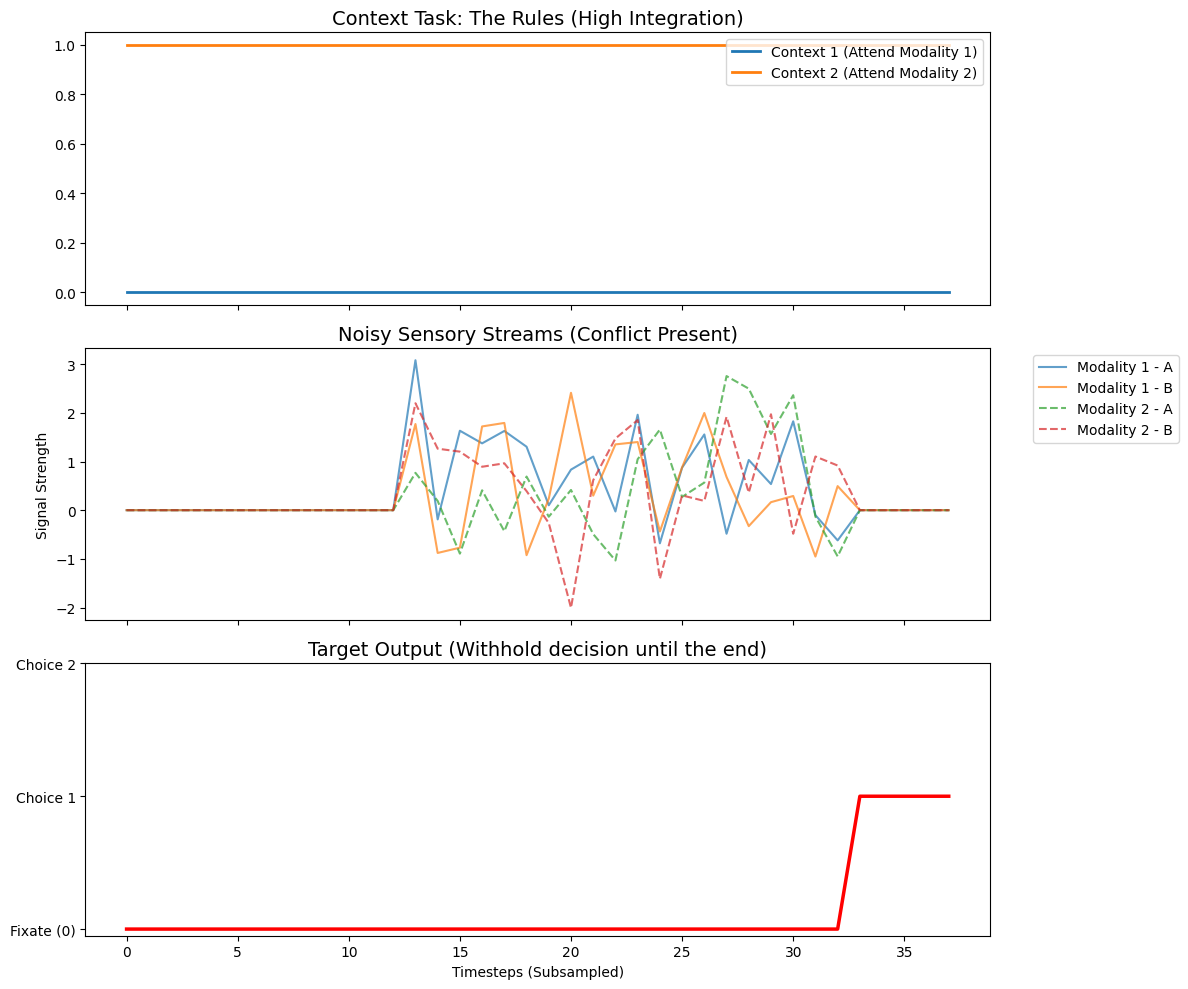

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Plot the Rules (Context Cues)
axes[0].plot(ctx_obs[:, 5], label="Context 1 (Attend Modality 1)", color="#1f77b4", linewidth=2)
axes[0].plot(ctx_obs[:, 6], label="Context 2 (Attend Modality 2)", color="#ff7f0e", linewidth=2)
axes[0].set_title("Context Task: The Rules (High Integration)", fontsize=14)
axes[0].legend(loc="upper right")

# 2. Plot the Noisy Sensory Streams (Both are active!)
axes[1].plot(ctx_obs[:, 1], label="Modality 1 - A", color="#1f77b4", alpha=0.7)
axes[1].plot(ctx_obs[:, 2], label="Modality 1 - B", color="#ff7f0e", alpha=0.7)
axes[1].plot(ctx_obs[:, 3], label="Modality 2 - A", color="#2ca02c", linestyle='--', alpha=0.7)
axes[1].plot(ctx_obs[:, 4], label="Modality 2 - B", color="#d62728", linestyle='--', alpha=0.7)
axes[1].set_title("Noisy Sensory Streams (Conflict Present)", fontsize=14)
axes[1].set_ylabel("Signal Strength")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")

# 3. Plot the Target Output
axes[2].plot(ctx_labels, color="red", linewidth=2.5, label="Target Output")
axes[2].set_title("Target Output (Withhold decision until the end)", fontsize=14)
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(["Fixate (0)", "Choice 1", "Choice 2"])
axes[2].set_xlabel("Timesteps (Subsampled)")

plt.tight_layout()
plt.show()